In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision import models, datasets
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [5]:

!unzip -qq "/content/drive/MyDrive/Deep Learning exp/chip_data.zip" -d data

In [32]:
# Load dataset from a folder (structured as: dataset/class_name/images)
dataset_path = "./data/dataset/"
train_dataset = datasets.ImageFolder(root=f"{dataset_path}/train", transform=transform)
test_dataset = datasets.ImageFolder(root=f"{dataset_path}/test", transform=transform)
print("Classes:", train_dataset.classes)
print("Class to index:", train_dataset.class_to_idx)

Classes: ['defect', 'notdefect']
Class to index: {'defect': 0, 'notdefect': 1}


In [33]:
# Display some input images
def show_sample_images(dataset, num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(10, 5))

    for i in range(num_images):
        image, label = dataset[i]

        # Convert tensor format from C, H, W to H, W, C
        image = image.numpy().transpose((1, 2, 0))

        # Unnormalize image for correct display
        image = image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        image = np.clip(image, 0, 1)

        axes[i].imshow(image)
        axes[i].set_title(dataset.classes[label])
        axes[i].axis("off")

    plt.show()

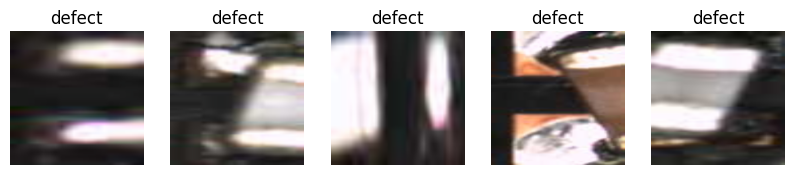

In [34]:
# Show sample images from the training dataset
show_sample_images(train_dataset)

In [35]:
# Get the total number of samples in the training dataset
print(f"Total number of training samples: {len(train_dataset)}")

# Get the shape of the first image in the dataset
first_image, label = train_dataset[0]
print(f"Shape of the first image: {first_image.shape}")

Total number of training samples: 172
Shape of the first image: torch.Size([3, 224, 224])


In [12]:
# Get the total number of samples in the testing dataset
print(f"Total number of testing samples: {len(test_dataset)}")

# Get the shape of the first image in the dataset
first_image1,label=test_dataset[0]
print(f"Shape of the first image:{first_image1.shape}")


Total number of testing samples: 121
Shape of the first image:torch.Size([3, 224, 224])


In [13]:
# Create DataLoader for batch processing
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [36]:
## Step 2: Load Pretrained Model and Modify for Transfer Learning
# Load a pre-trained VGG19 model
# write your code here
from torchvision.models import VGG19_Weights
model=models.vgg19(weights=VGG19_Weights.DEFAULT)

In [37]:
# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [38]:
from torchsummary import summary
# Print model summary
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

In [39]:
# Modify the final fully connected layer to match the dataset classes
# Write your code here

for param in model.classifier[-1].parameters():
    param.requires_grad = True
model.classifier[-1]=nn.Linear(model.classifier[-1].in_features,1)



In [40]:
# Move model to GPU if available
for param in model.classifier[-1].parameters():
    param.requires_grad = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [41]:
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

In [42]:
# Freeze all layers except the final layer
for param in model.features.parameters():
    param.requires_grad = False  # Freeze feature extractor layers

In [47]:
criterion = nn.BCEWithLogitsLoss()

# Optimizer updates only the final layer parameters
optimizer = optim.Adam(model.classifier[-1].parameters(), lr=0.001)


In [48]:
def train_model(model, train_loader, test_loader, num_epochs=20):
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        # Training loop
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            # Clear previous gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Convert labels to float and reshape for BCEWithLogitsLoss
            loss = criterion(outputs, labels.unsqueeze(1).float())

            # Backward pass
            loss.backward()

            # Update weights
            optimizer.step()

            running_loss += loss.item()

        # Calculate average training loss
        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # Validation loop
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels.unsqueeze(1).float())
                val_loss += loss.item()

        # Calculate average validation loss
        val_loss = val_loss / len(test_loader)
        val_losses.append(val_loss)

        print(f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

    # Plot training and validation loss
    print("Name: ARCHANA T")
    print("Register Number: 212223240013")

    plt.figure(figsize=(8, 6))
    plt.plot(range(1, num_epochs + 1), train_losses, label="Train Loss", marker="o")
    plt.plot(range(1, num_epochs + 1), val_losses, label="Validation Loss", marker="s")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.show()

In [49]:
# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

Epoch [1/20], Train Loss: 0.3110, Validation Loss: 0.2596
Epoch [2/20], Train Loss: 0.2460, Validation Loss: 0.2284
Epoch [3/20], Train Loss: 0.1971, Validation Loss: 0.2120
Epoch [4/20], Train Loss: 0.1989, Validation Loss: 0.2075
Epoch [5/20], Train Loss: 0.1597, Validation Loss: 0.1886
Epoch [6/20], Train Loss: 0.1364, Validation Loss: 0.1784
Epoch [7/20], Train Loss: 0.1207, Validation Loss: 0.1775
Epoch [8/20], Train Loss: 0.1200, Validation Loss: 0.1691
Epoch [9/20], Train Loss: 0.1073, Validation Loss: 0.1642
Epoch [10/20], Train Loss: 0.1017, Validation Loss: 0.1607
Epoch [11/20], Train Loss: 0.1093, Validation Loss: 0.1612
Epoch [12/20], Train Loss: 0.0907, Validation Loss: 0.1580
Epoch [13/20], Train Loss: 0.0845, Validation Loss: 0.1596
Epoch [14/20], Train Loss: 0.0758, Validation Loss: 0.1517
Epoch [15/20], Train Loss: 0.0803, Validation Loss: 0.1504
Epoch [16/20], Train Loss: 0.0750, Validation Loss: 0.1507
Epoch [17/20], Train Loss: 0.0669, Validation Loss: 0.1474
Epoch 

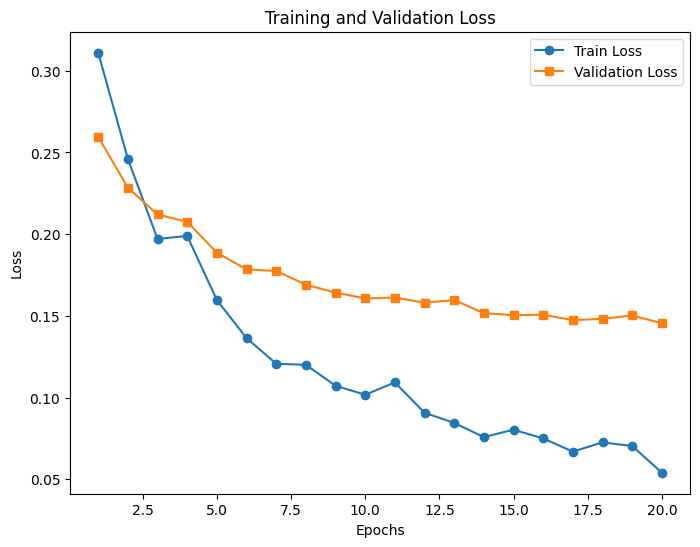

In [50]:
# Train the model
# Write your code here

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

train_model(model, train_loader, test_loader, num_epochs=20)

In [51]:
def test_model(model, test_loader):
    model.eval()

    all_preds = []
    all_labels = []
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            # Get raw output from model
            outputs = model(images)

            # Apply sigmoid to convert output to probability
            probs = torch.sigmoid(outputs)

            # Convert probability to class label
            # If probability > 0.5, predicted class is 1
            # Otherwise predicted class is 0
            preds = (probs > 0.5).int().squeeze()

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate test accuracy
    accuracy = correct / total
    print(f"Test Accuracy: {accuracy:.4f}")

    # Create confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    print("Name: ARCHANA T")
    print("Register Number: 212223240013")

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=train_dataset.classes,
        yticklabels=train_dataset.classes
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    print("Name: ARCHANA T")
    print("Register Number: 212223240013")

    print("Classification Report:")
    print(
        classification_report(
            all_labels,
            all_preds,
            target_names=train_dataset.classes,
            zero_division=0
        )
    )

Test Accuracy: 0.9421
Name: ARCHANA T
Register Number: 212223240013


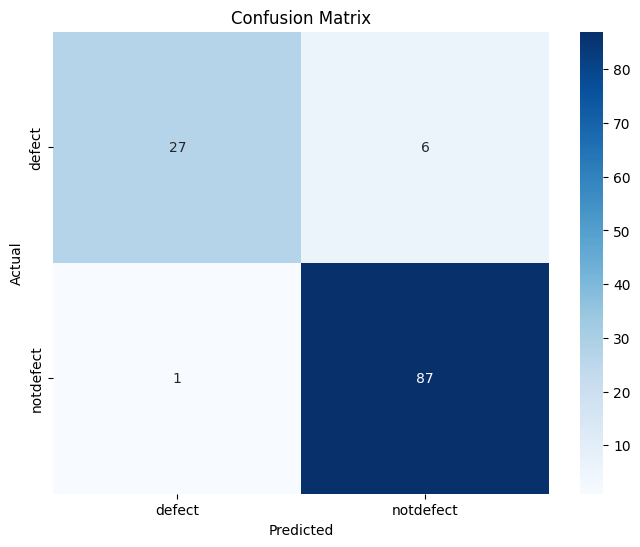

Name: ARCHANA T
Register Number: 212223240013
Classification Report:
              precision    recall  f1-score   support

      defect       0.96      0.82      0.89        33
   notdefect       0.94      0.99      0.96        88

    accuracy                           0.94       121
   macro avg       0.95      0.90      0.92       121
weighted avg       0.94      0.94      0.94       121



In [52]:
# Evaluate the model
# write your code here
test_model(model,test_loader)



In [56]:
## Step 5: Predict on a Single Image and Display It
def predict_image(model, image_index, dataset):
    model.eval()

    image, label = dataset[image_index]

    with torch.no_grad():
        image_tensor = image.unsqueeze(0).to(device)
        output = model(image_tensor)

        # Apply sigmoid to get probability, threshold at 0.5
        prob = torch.sigmoid(output)
        predicted = (prob > 0.5).int().squeeze().item()

    class_names = dataset.classes

    # Convert tensor image from C,H,W to H,W,C
    image_to_display = image.cpu().numpy().transpose((1, 2, 0))

    # Unnormalize image for correct display
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image_to_display = image_to_display * std + mean
    image_to_display = np.clip(image_to_display, 0, 1)

    # Display the image
    plt.figure(figsize=(4, 4))
    plt.imshow(image_to_display)
    plt.title(f'Actual: {class_names[label]}\nPredicted: {class_names[predicted]}')
    plt.axis("off")
    plt.show()

    print(f'Actual: {class_names[label]}, Predicted: {class_names[predicted]}')

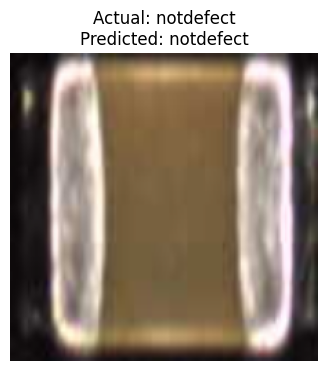

Actual: notdefect, Predicted: notdefect


In [57]:
# Example Prediction
predict_image(model, image_index=55, dataset=test_dataset)


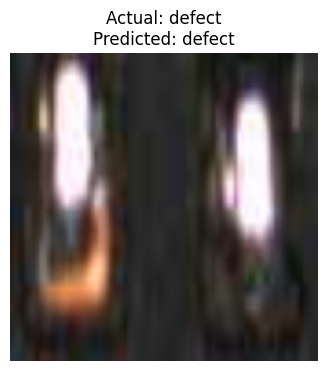

Actual: defect, Predicted: defect


In [58]:
#Example Prediction
predict_image(model, image_index=25, dataset=test_dataset)